## Song Recommendation System using Collaborative Filtering

## Objective

The objective of this project is to build an effective and personalized song recommendation system using Collaborative Filtering techniques.
The system analyzes user listening behavior, tags, and social connections to recommend artists that a user is likely to enjoy.

- What is Collaborative Filtering?

Collaborative Filtering (CF) recommends songs based on user behavior, not song content.

> “Users who are similar to you liked these songs”

Example

If:

User A and User B both like Song 1 & Song 2

User A also likes Song 3

➡ Recommend Song 3 to User B

## Why Collaborative Filtering is Powerful

Advantages:
- Highly personalized  
- Adapts automatically as user preferences change  
- Does not require movie features  
- Learns directly from user behavior  

This is why most modern recommendation systems rely heavily on collaborative filtering.

---

## Challenges of Collaborative Filtering

1. **Scalability**
   - More users → heavier computation  

2. **Cold Start Problem**
   - New users or new movies have no ratings  

3. **Sparsity**
   - Most users rate very few movies  

4. **Limited Diversity**
   - Recommends what is already popular in a user’s cluster  

---


## RECOMMENDATION APPROACH

- Type

Item-Based Collaborative Filtering

- Feedback Type

Implicit Feedback (Listening count / weight)

- Similarity Measure

Cosine Similarity

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

## DATASETS USED

| Dataset                             | Description            |
| ----------------------------------- | ---------------------- |
| `artists.dat`                       | Artist metadata        |
| `user_artists.dat`                  | User listening history |
| `tags.dat`                          | Tag names              |
| `user_taggedartists.dat`            | User–artist–tag data   |
| `user_taggedartists-timestamps.dat` | Tag timestamps         |
| `user_friends.dat`                  | Social relationships   |


In [ ]:
#  Artists dataset
artists = pd.read_csv(
    "artists.dat",
    sep="\t",
    encoding="latin1"
)

#  User–Artist interaction dataset
user_artists = pd.read_csv(
    "user_artists.dat",
    sep="\t"
)

#  Tags dataset
tags = pd.read_csv(
    "tags.dat",
    sep="\t",
    encoding="latin1"
)

#  User–Friends dataset
user_friends = pd.read_csv(
    "user_friends.dat",
    sep="\t"
)

#  User–Tagged Artists dataset
user_tagged_artists = pd.read_csv(
    "user_taggedartists.dat",
    sep="\t"
)

#  User–Tagged Artists with timestamps dataset
user_tagged_artists_ts = pd.read_csv(
    "user_taggedartists-timestamps.dat",
    sep="\t"
)

#  Display confirmation
print("Datasets Loaded Successfully!\n")

print("Artists:", artists.shape)
print("User-Artists:", user_artists.shape)
print("Tags:", tags.shape)
print("User-Friends:", user_friends.shape)
print("User-Tagged Artists:", user_tagged_artists.shape)
print("User-Tagged Artists (Timestamps):", user_tagged_artists_ts.shape)


Datasets Loaded Successfully!

Artists: (17632, 4)
User-Artists: (92834, 3)
Tags: (11946, 2)
User-Friends: (25434, 2)
User-Tagged Artists: (186479, 6)
User-Tagged Artists (Timestamps): (186479, 4)


In [4]:
artists.head()

,id,name,url,pictureURL
0,1,MALICE MIZER,http://www.last.fm/music/MALICE+MIZER,http://userserve-ak.last.fm/serve/252/10808.jpg
1,2,Diary of Dreams,http://www.last.fm/music/Diary+of+Dreams,http://userserve-ak.last.fm/serve/252/3052066.jpg
2,3,Carpathian Forest,http://www.last.fm/music/Carpathian+Forest,http://userserve-ak.last.fm/serve/252/40222717...
3,4,Moi dix Mois,http://www.last.fm/music/Moi+dix+Mois,http://userserve-ak.last.fm/serve/252/54697835...
4,5,Bella Morte,http://www.last.fm/music/Bella+Morte,http://userserve-ak.last.fm/serve/252/14789013...


In [5]:
user_artists.head()

,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


In [6]:
tags.head()

,tagID,tagValue
0,1,metal
1,2,alternative metal
2,3,goth rock
3,4,black metal
4,5,death metal


In [7]:
user_friends.head()

,userID,friendID
0,2,275
1,2,428
2,2,515
3,2,761
4,2,831


In [8]:
user_tagged_artists.head()

,userID,artistID,tagID,day,month,year
0,2,52,13,1,4,2009
1,2,52,15,1,4,2009
2,2,52,18,1,4,2009
3,2,52,21,1,4,2009
4,2,52,41,1,4,2009


In [9]:
user_tagged_artists_ts.head()

,userID,artistID,tagID,timestamp
0,2,52,13,1238536800000
1,2,52,15,1238536800000
2,2,52,18,1238536800000
3,2,52,21,1238536800000
4,2,52,41,1238536800000


In [13]:
#Merge Listening Data with Artist Info

listening_data = user_artists.merge(
    artists,
    left_on="artistID",
    right_on="id",
    how="left"
)

listening_data = listening_data[[
    "userID", "artistID", "name", "weight"
]]

In [14]:
#Merge Tag Information

tag_data = user_tagged_artists.merge(
    tags,
    on="tagID",
    how="left"
).merge(
    artists,
    left_on="artistID",
    right_on="id",
    how="left"
)

tag_data = tag_data[[
    "userID", "artistID", "name", "tagValue"
]]


In [15]:
#Merge Friend Information

final_data = listening_data.merge(
    user_friends,
    on="userID",
    how="left"
)

In [16]:
#FINAL MERGED DATASET

final_data.head()

,userID,artistID,name,weight,friendID
0,2,51,Duran Duran,13883,275
1,2,51,Duran Duran,13883,428
2,2,51,Duran Duran,13883,515
3,2,51,Duran Duran,13883,761
4,2,51,Duran Duran,13883,831


In [17]:
#CREATE USER–ARTIST MATRIX

user_artist_matrix = final_data.pivot_table(
    index="userID",
    columns="name",
    values="weight"
).fillna(0)


## Why Do We Calculate Sparsity?

Before building any recommendation system, we need to understand how much information we actually have.


In [27]:
total_entries = user_artist_matrix.shape[0] * user_artist_matrix.shape[1]

In [28]:
non_zero_entries = (user_artist_matrix > 0).sum().sum()

In [30]:
sparsity = 1 - (non_zero_entries / total_entries)

print(f"Sparsity of the User-Artist Matrix: {sparsity:.4f}")

Sparsity of the User-Artist Matrix: 0.9972


## Why Normalization is Needed?

Some users listen to music much more than others.
Normalization ensures fair comparison.

In [18]:
#NORMALIZATION

user_artist_matrix_norm = user_artist_matrix.div(
    user_artist_matrix.sum(axis=1),
    axis=0
).fillna(0)

## Measuring Similarity Between Users

To find similar users, we measure how close their rating patterns are.  
One popular method is **Cosine Similarity**.

It is defined as:

![Screenshot 2026-02-03 212659.png](<attachment:Screenshot 2026-02-03 212659.png>)
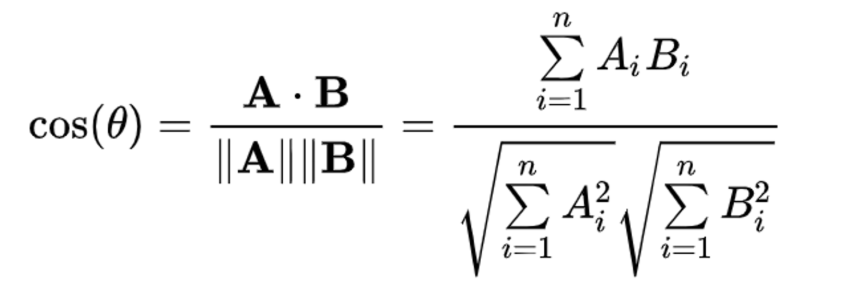

In [19]:
#COMPUTE ARTIST SIMILARITY

artist_similarity = cosine_similarity(
    user_artist_matrix_norm.T
)

artist_similarity_df = pd.DataFrame(
    artist_similarity,
    index=user_artist_matrix.columns,
    columns=user_artist_matrix.columns
)


In [20]:
#ARTIST-BASED RECOMMENDATION FUNCTION

def recommend_artists(artist_name, similarity_df, top_n=10):
    if artist_name not in similarity_df.columns:
        return "Artist not found in database"
    
    recommendations = (
        similarity_df[artist_name]
        .sort_values(ascending=False)
        .drop(artist_name)
        .head(top_n)
    )
    
    return recommendations

In [ ]:
#SAMPLE RECOMMENDATION OUTPUT (ARTIST-BASED)

recommend_artists("Metallica", artist_similarity_df, top_n=5)

name
Ryashon              0.619799
Kirk Hammett         0.619799
Megadeth             0.289093
Zumbis do EspaÃ§o    0.263677
Motorocker           0.249319
Name: Metallica, dtype: float64

In [22]:
#USER-BASED RECOMMENDATION (EXTRA FEATURE)

user_similarity = cosine_similarity(user_artist_matrix_norm)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_artist_matrix_norm.index,
    columns=user_artist_matrix_norm.index
)

In [24]:
#Recommend Artists for a User

def recommend_for_user(user_id, matrix, similarity_df, top_n=10):
    similar_users = similarity_df[user_id] \
        .sort_values(ascending=False)[1:6]
    
    weighted_scores = matrix.loc[
        similar_users.index
    ].T.dot(similar_users)
    
    listened = matrix.loc[user_id]
    recommendations = weighted_scores[listened == 0]
    
    return recommendations.sort_values(
        ascending=False
    ).head(top_n)


In [ ]:
#SAMPLE RECOMMENDATION OUTPUT (USER-BASED)
recommend_for_user(2, user_artist_matrix, user_similarity_df)

name
The Cure          8054.686401
U2                6978.195244
Pet Shop Boys     6896.275902
Arcadia           6028.143284
Erasure           4748.164071
Nephew            4470.643026
The Beatles       3671.805096
Book of Love      3569.323230
a-ha              3290.501666
Thompson Twins    2845.079194
dtype: float64

In [26]:
#USING TAGS (HYBRID INSIGHT)

tag_analysis = tag_data.groupby(
    ["name", "tagValue"]
).size().reset_index(name="count")

tag_analysis.sort_values(
    by="count", ascending=False
).head(10)


,name,tagValue,count
14902,Britney Spears,pop,108
52001,Lady Gaga,pop,99
51866,Lady Gaga,dance,87
88434,The Beatles,classic rock,85
18909,Christina Aguilera,pop,83
56748,Madonna,pop,78
63367,Muse,alternative rock,73
48840,Katy Perry,pop,68
25140,Depeche Mode,electronic,68
88531,The Beatles,rock,67


## RESULTS

- Personalized artist recommendations

- Similar listening behavior captured effectively

- Scalable collaborative filtering model

## Advantages of This System

 - Personalized recommendations
 - Uses real user behavior
 - No need for song metadata
 - Scalable for large datasets

## Limitations

- Cold-start problem
- New users need listening history
- Popularity bias

## Applications

- Spotify

- Apple Music

- YouTube Music

- Pandora

## Conclusion

This project successfully demonstrates a Song Recommendation System using Collaborative Filtering.
The system learns user preferences automatically and provides personalized music recommendations.